# Waiting Times: Load Factor vs Wait Time

Seaborn-only analysis using `waiting_times.csv`:
- Compute load factor = `GUEST_CARRIED / CAPACITY`
- Correlation between `WAIT_TIME_MAX` and load factor per attraction
- Scatter plots per attraction
- Correlation matrix for `WAIT_TIME_MAX` and load factor


In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from textwrap import fill
from IPython.display import display

sns.set_theme(style="whitegrid")


In [46]:
# Resolve data path
cwd = Path.cwd()
if (cwd / "src" / "data" / "waiting_times.csv").exists():
    waiting_path = cwd / "src" / "data" / "waiting_times.csv"
elif (cwd / "data" / "waiting_times.csv").exists():
    waiting_path = cwd / "data" / "waiting_times.csv"
else:
    waiting_path = Path("src/data/waiting_times.csv")

waiting_path


WindowsPath('c:/Users/artur/Desktop/ESSEC MS IN DATA SCIENCE/0 STUDY/M2/Hackathon/code/src/data/waiting_times.csv')

In [ ]:
df = pd.read_csv(
    waiting_path,
    parse_dates=["WORK_DATE", "DEB_TIME", "FIN_TIME"],
    low_memory=False,
)

for col in ["WAIT_TIME_MAX", "GUEST_CARRIED", "CAPACITY"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Load factor = GUEST_CARRIED / CAPACITY
df["load_factor"] = np.where(
    df["CAPACITY"] > 0,
    df["GUEST_CARRIED"] / df["CAPACITY"],
    np.nan,
)

base = df[
    [
        "WORK_DATE",
        "ENTITY_DESCRIPTION_SHORT",
        "WAIT_TIME_MAX",
        "GUEST_CARRIED",
        "CAPACITY",
        "load_factor",
    ]
].dropna()

base.head()


,WORK_DATE,ENTITY_DESCRIPTION_SHORT,WAIT_TIME_MAX,GUEST_CARRIED,CAPACITY,load_factor
1,2018-01-01,Bumper Cars,5,148.0,254.749,0.580964
3,2018-01-01,Crazy Dance,5,46.0,250.001,0.183999
4,2018-01-01,Skyway,5,92.0,211.500,0.434988
6,2018-01-01,Monorail,70,145.0,223.751,0.648042
7,2018-01-01,Roller Coaster,20,51.0,75.000,0.680000


In [48]:
# Quick check: load factor distribution
base[["load_factor", "WAIT_TIME_MAX"]].describe().T


,count,mean,std,min,25%,50%,75%,max
load_factor,1880430.0,0.469002,0.252010,-1.091947,0.310588,0.491269,0.638957,42.857143
WAIT_TIME_MAX,1880430.0,25.092293,23.004001,0.000000,5.000000,15.000000,35.000000,300.000000


Text(47.24999999999999, 0.5, 'Attraction')

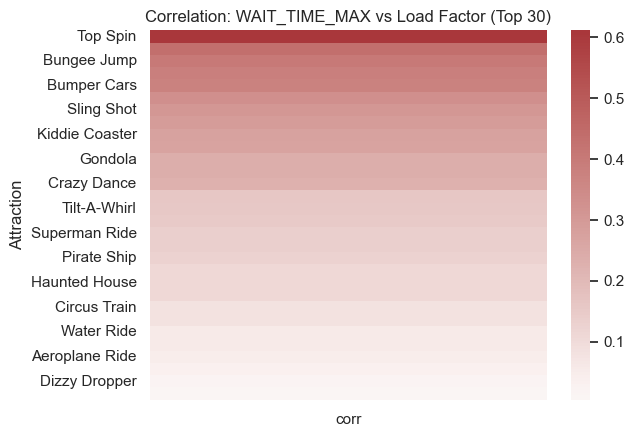

In [49]:
def correlation_by_attraction(min_n=200):
    corr_matrix = (
        base.groupby("ENTITY_DESCRIPTION_SHORT")[["WAIT_TIME_MAX", "load_factor"]]
        .corr()
        .unstack()
    )

    corr_by_entity = corr_matrix.loc[:, ("WAIT_TIME_MAX", "load_factor")].rename("corr").to_frame()
    corr_by_entity["n"] = base.groupby("ENTITY_DESCRIPTION_SHORT").size()
    corr_by_entity = corr_by_entity[corr_by_entity["n"] >= min_n]
    return corr_by_entity.sort_values("corr", ascending=False)


# Correlation between WAIT_TIME_MAX and load factor per attraction
corr_by_entity = correlation_by_attraction(min_n=200)

ax = sns.heatmap(corr_by_entity[["corr"]].head(30), cmap="vlag", center=0)
ax.set_title("Correlation: WAIT_TIME_MAX vs Load Factor (Top 30)")
ax.set_xlabel("")
ax.set_ylabel("Attraction")


,WORK_DATE,rolling_corr,ENTITY_DESCRIPTION_SHORT
1427,2021-11-28,0.651434,Giga Coaster
1529,2022-03-10,0.590026,Crazy Dance
1690,2022-08-18,0.564796,Skyway
1690,2022-08-18,0.503544,Reverse Bungee
1690,2022-08-18,0.425943,Kiddie Coaster
1690,2022-08-18,0.382419,Oz Theatre
1690,2022-08-18,0.375982,Power Tower
1690,2022-08-18,0.345788,Flying Coaster
1690,2022-08-18,0.308454,Merry Go Round
1690,2022-08-18,0.144847,Sling Shot


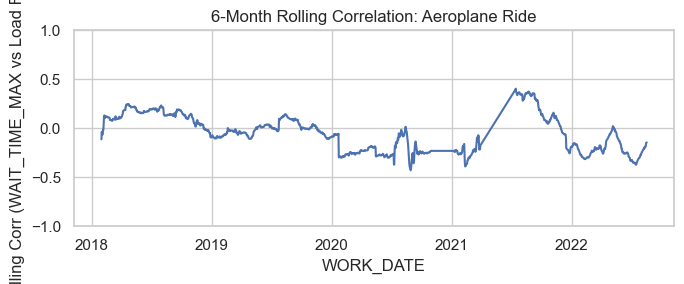

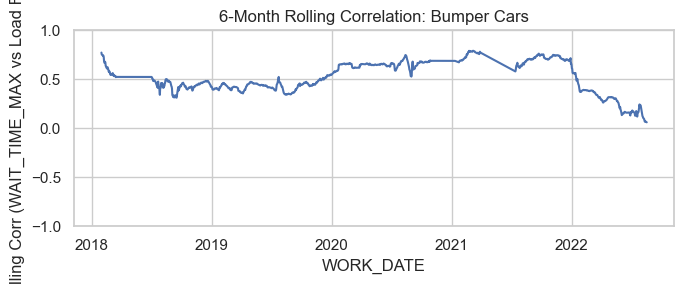

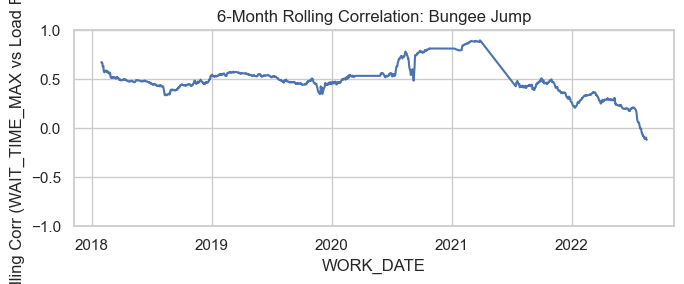

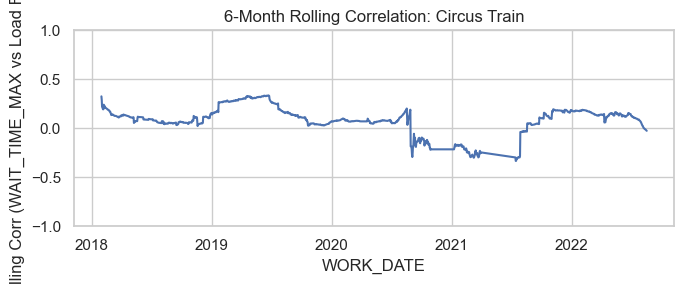

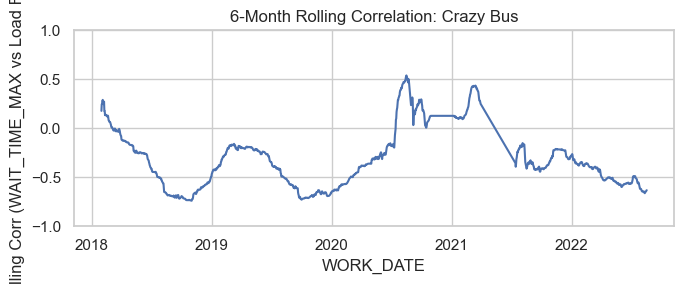

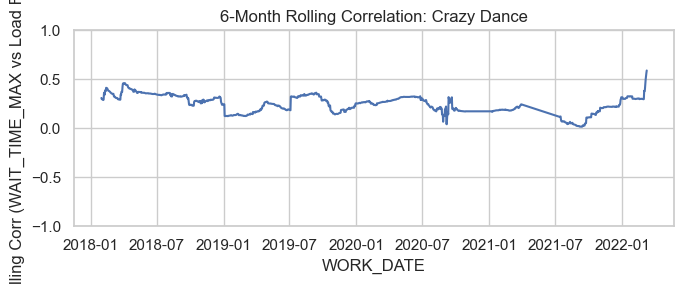

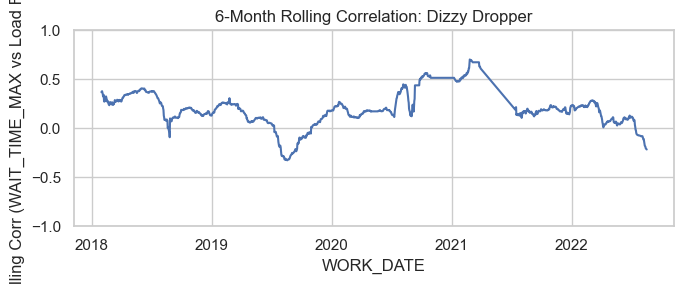

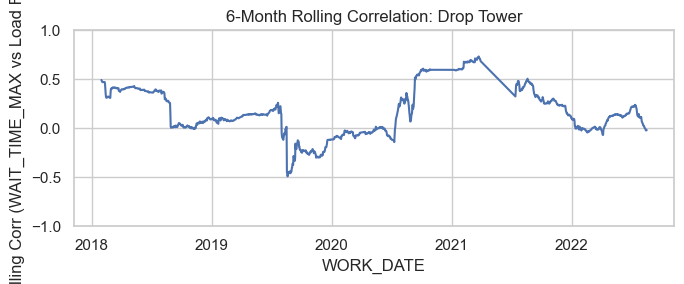

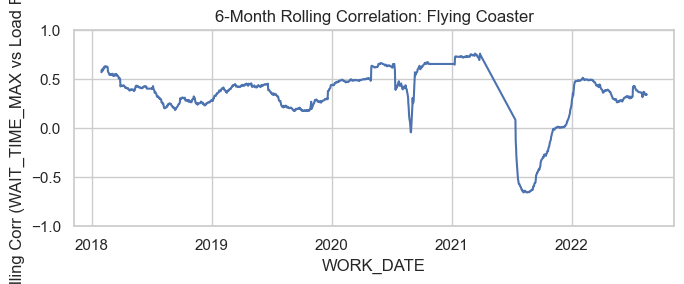

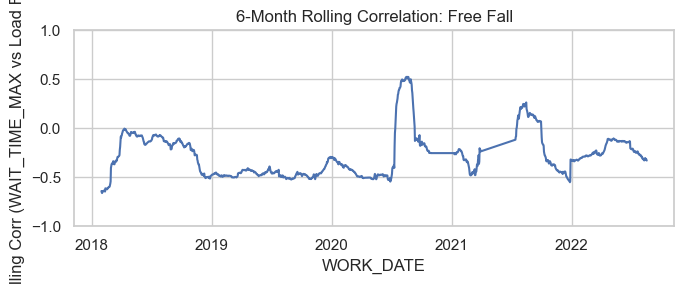

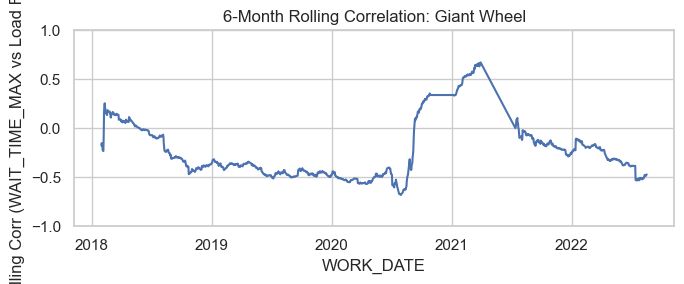

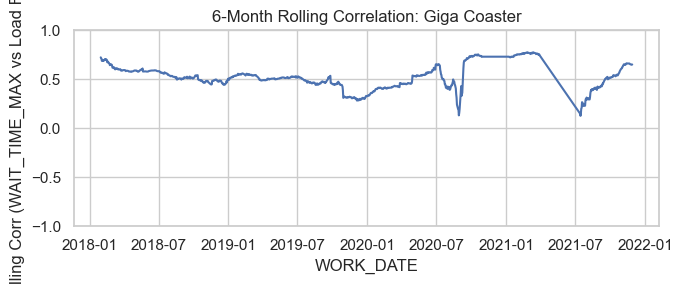

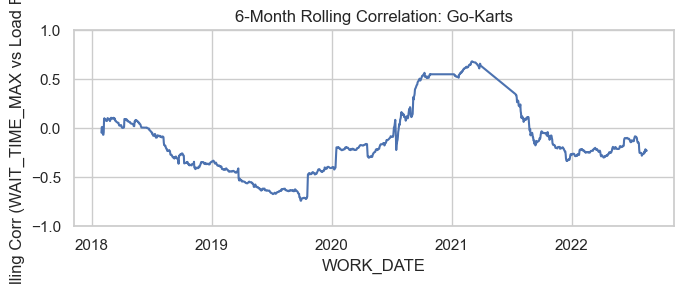

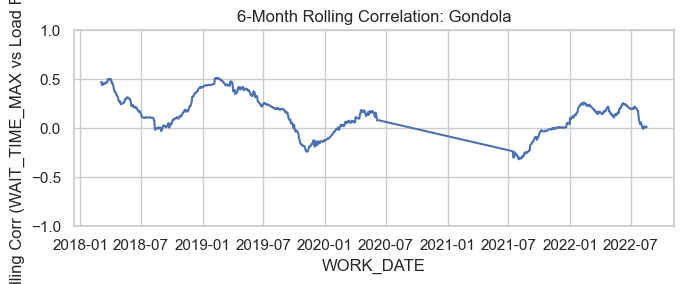

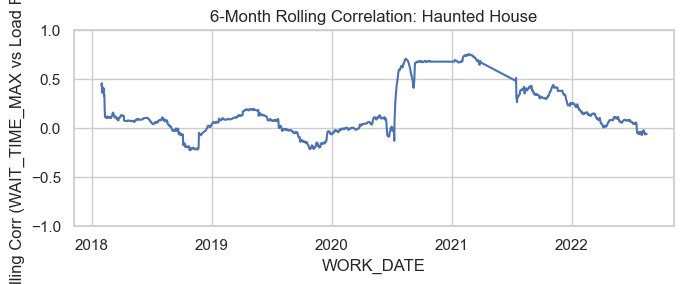

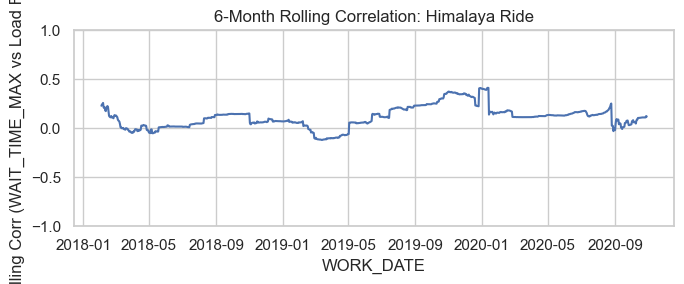

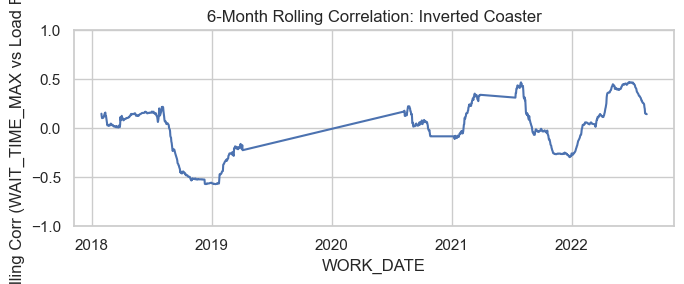

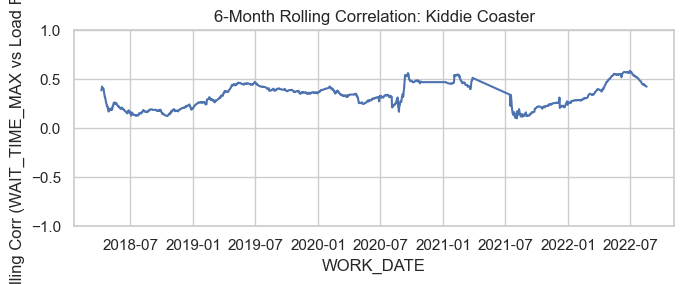

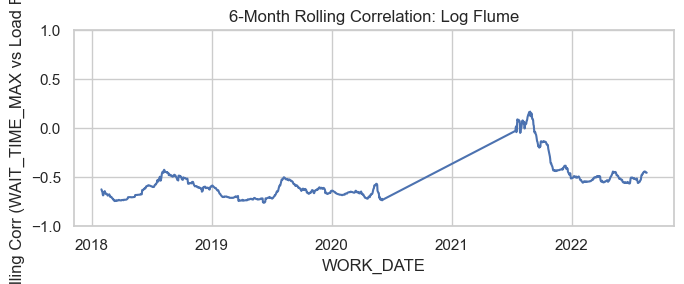

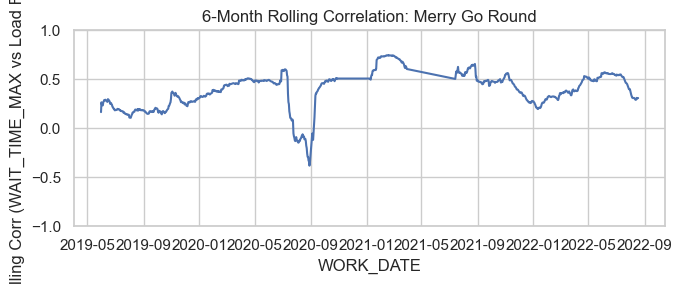

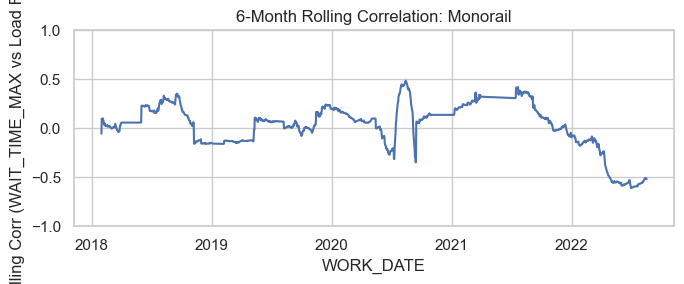

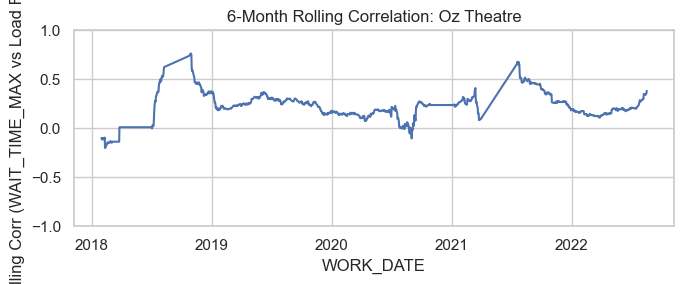

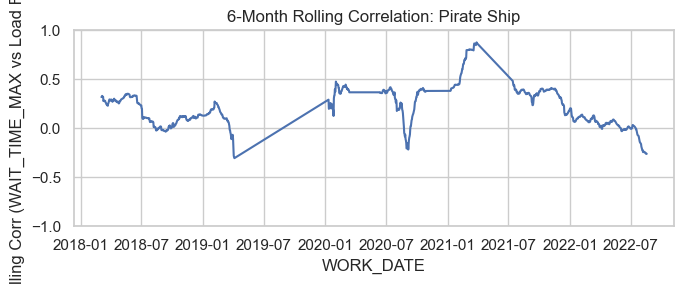

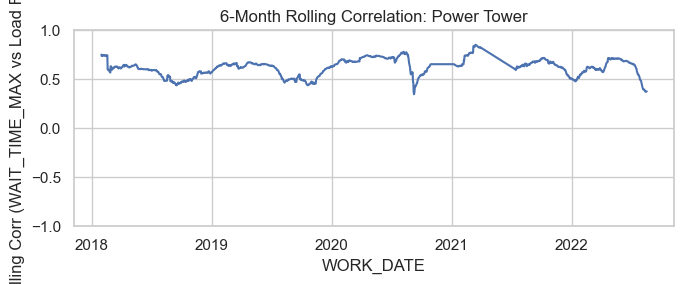

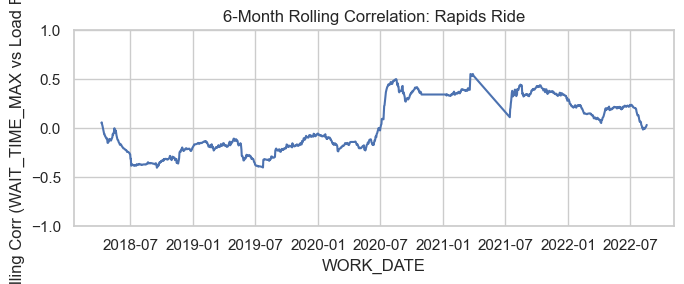

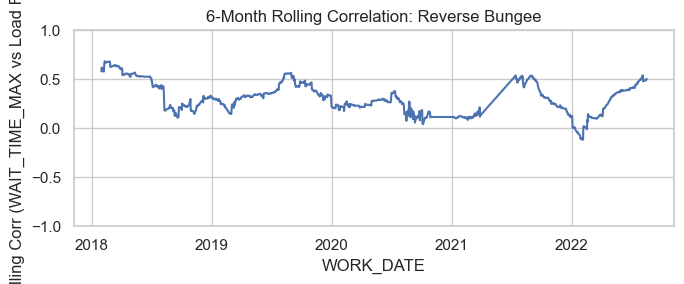

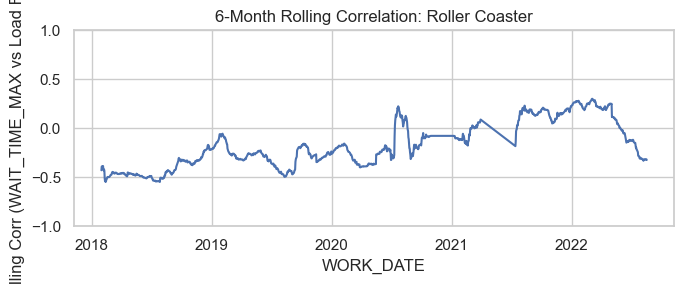

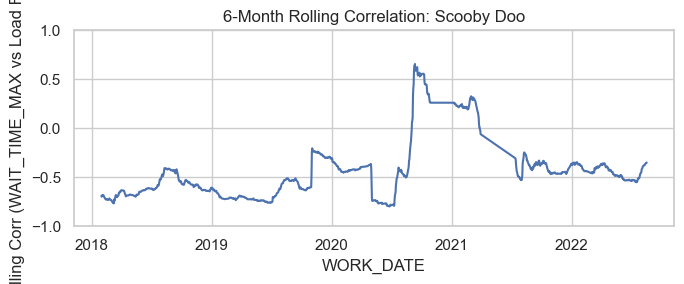

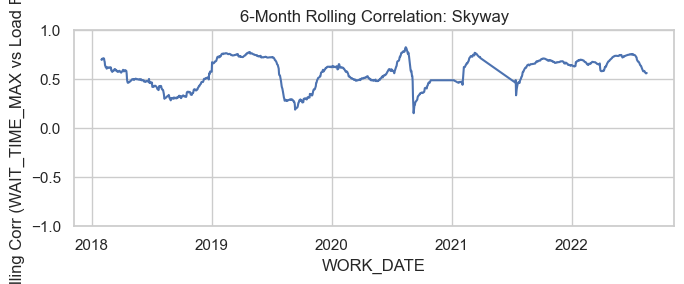

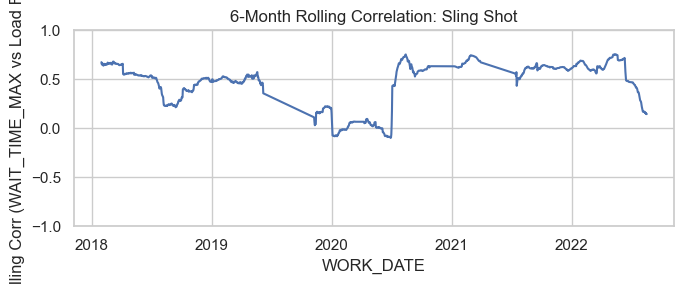

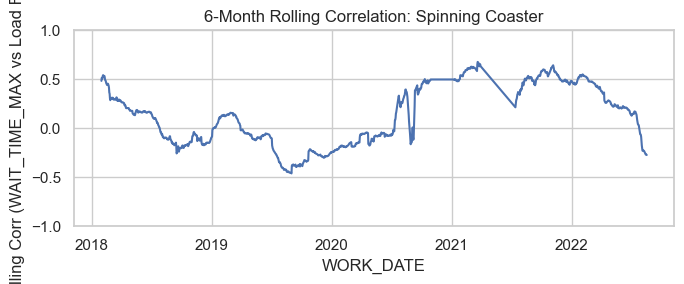

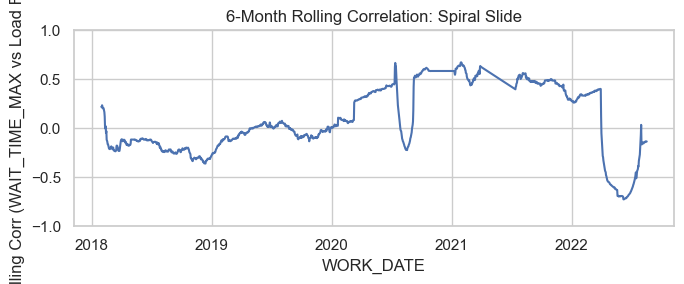

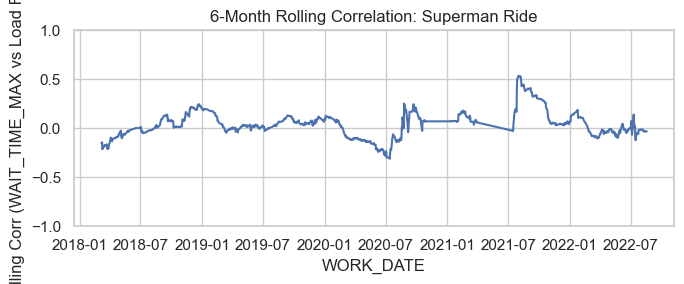

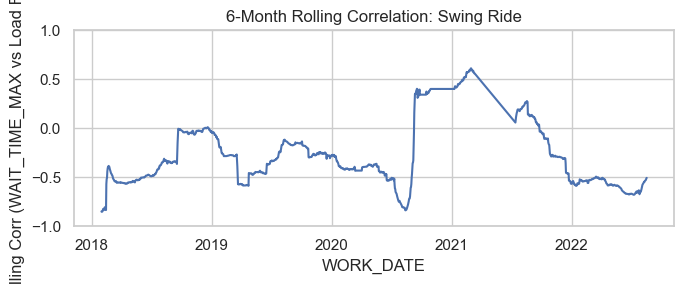

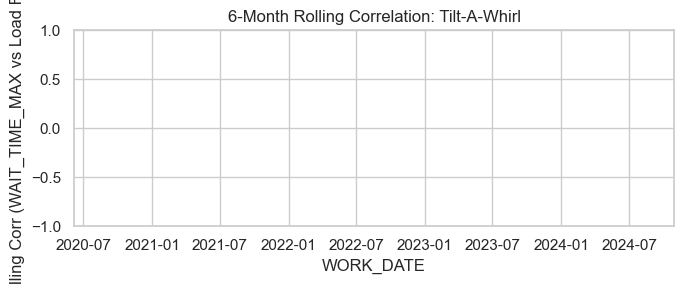

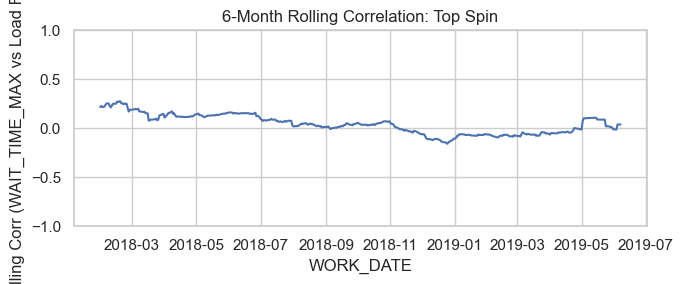

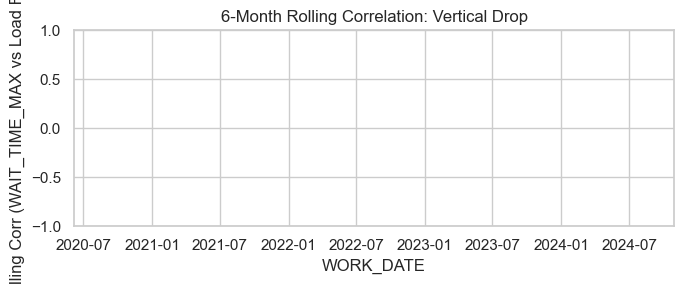

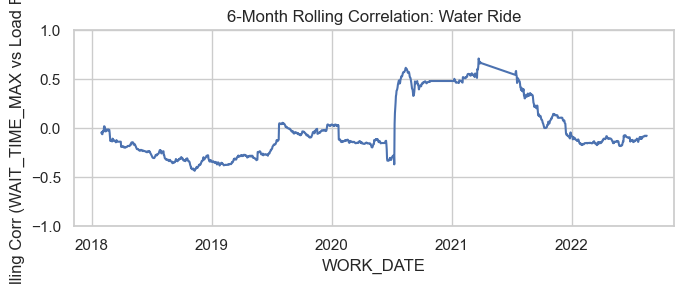

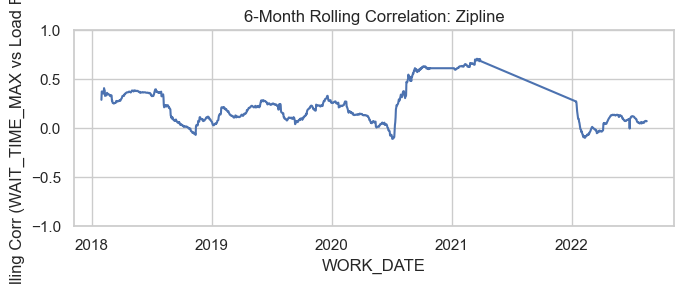

In [52]:
# 4-week rolling correlation per attraction
rolling_base = base[["WORK_DATE", "ENTITY_DESCRIPTION_SHORT", "WAIT_TIME_MAX", "load_factor"]].copy()

rolling_base = rolling_base.sort_values(["ENTITY_DESCRIPTION_SHORT", "WORK_DATE"])


def rolling_corr_by_attraction(data, window="182D", min_periods=30):
    def _calc(g):
        daily = (
            g.set_index("WORK_DATE")[["WAIT_TIME_MAX", "load_factor"]]
            .resample("D")
            .mean()
        )
        rolling = daily.rolling(window, min_periods=min_periods).corr().unstack()
        corr = rolling.loc[:, ("WAIT_TIME_MAX", "load_factor")].rename("rolling_corr")
        out = corr.reset_index()
        out["ENTITY_DESCRIPTION_SHORT"] = g.name
        return out

    return data.groupby("ENTITY_DESCRIPTION_SHORT", group_keys=False).apply(_calc)


rolling_corr = rolling_corr_by_attraction(rolling_base, window="182D", min_periods=30)

# Latest available rolling correlation per attraction
latest_corr = (
    rolling_corr.sort_values(["ENTITY_DESCRIPTION_SHORT", "WORK_DATE"])
    .groupby("ENTITY_DESCRIPTION_SHORT", as_index=False)
    .tail(1)
    .sort_values("rolling_corr", ascending=False)
)

display(latest_corr.head(20))

# Individual plots per attraction (6-month rolling correlation)
for name, g in rolling_corr.groupby("ENTITY_DESCRIPTION_SHORT"):
    plot_df = g.dropna(subset=["rolling_corr"])
    if plot_df.empty:
        continue

    plt.figure(figsize=(7, 3))
    sns.lineplot(data=plot_df, x="WORK_DATE", y="rolling_corr")
    plt.title(f"6-Month Rolling Correlation: {name}")
    plt.xlabel("WORK_DATE")
    plt.ylabel("Rolling Corr (WAIT_TIME_MAX vs Load Factor)")
    plt.ylim(-1, 1)
    plt.tight_layout()
    plt.show()


In [44]:
# Correlation table (all attractions)
display(corr_by_entity.head(15))

display(corr_by_entity.tail(15))


,corr,n
ENTITY_DESCRIPTION_SHORT,,
Top Spin,0.611321,19735
Skyway,0.437665,53832
Bungee Jump,0.403812,57605
Power Tower,0.385049,54167
Bumper Cars,0.372201,55232
Flying Coaster,0.329335,60001
Sling Shot,0.306566,43710
Giga Coaster,0.293191,47762
Kiddie Coaster,0.274945,46773


,corr,n
ENTITY_DESCRIPTION_SHORT,,
Water Ride,0.058726,58574
Spinning Coaster,0.058644,65309
Aeroplane Ride,0.045429,55409
Himalaya Ride,0.033607,36725
Dizzy Dropper,0.018719,59605
Monorail,0.004435,52886
Roller Coaster,-0.059505,44774
Go-Karts,-0.081662,63173
Inverted Coaster,-0.087024,26687
